# Install Libraries
## Uncomment below if using Github

In [ ]:
#!wget https://github.com/Munazaa/Flood-Mapping-Case/raw/main/requirements.txt

In [ ]:
#!pip install -r requirements.txt

In [4]:
# !pip install rasterio numpy geopandas matplotlib shapely pillow contextily

In [5]:
# import rasterio
# import numpy as np
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from rasterio import features
# from rasterio.features import shapes
# from shapely.geometry import shape
# from PIL import Image
# import os
# from rasterio import features
# import geopandas as gpd
# from rasterio.mask import mask
# import zipfile
# import contextily as ctx

In [3]:
import digitalhub as dh

# # Define project name
# project_name = "docker-sentinel"

# # Access the project
# project = dh.get_or_create_project(project_name)

# # List all artifacts in the project
# artifacts = project.list_artifacts()

# # Print available artifacts
# artifact_names = [artifact.name for artifact in artifacts]
# print("Available Artifacts in Project:", artifact_names)

In [4]:
project = dh.get_or_create_project('flood-mapping')

In [ ]:
#project.log_artifact('data', kind='artifact', source='data')
# project.log_artifact('sentinel2_post_flood', kind='artifact', source='sentinel2_post_flood')
# project.log_artifact('shapes', kind='artifact', source='shapes')

{'kind': 'artifact', 'metadata': {'project': 'flood-mapping', 'name': 'data', 'version': '13ad38d4c2374eb79205a47c57317aa5', 'created': '2025-05-19T13:31:07.305Z', 'updated': '2025-05-19T13:31:23.872Z', 'created_by': 'khurshid@fbk.eu', 'updated_by': 'khurshid@fbk.eu', 'embedded': False}, 'spec': {'path': 's3://datalake/flood-mapping/artifact/data/13ad38d4c2374eb79205a47c57317aa5/'}, 'status': {'state': 'CREATED', 'files': [{'path': 'AOI_Rec.shx', 'name': 'AOI_Rec.shx', 'content_type': 'application/x-qgis', 'size': 108, 'hash': 'md5:7e6e30318dc0f216c3ff4a294d4d22e3', 'last_modified': '2025-05-19T13:31:07+00:00'}, {'path': 'AOI_Rec.cpg', 'name': 'AOI_Rec.cpg', 'content_type': 'binary/octet-stream', 'size': 5, 'hash': 'md5:ae3b3df9970b49b6523e608759bc957d', 'last_modified': '2025-05-19T13:31:07+00:00'}, {'path': 'AOI_Rec.dbf', 'name': 'AOI_Rec.dbf', 'content_type': 'application/vnd.dbf', 'size': 73, 'hash': 'md5:46368f636c60af996481ed81fe1ec16f', 'last_modified': '2025-05-19T13:31:07+00:0

In [8]:
artifact_data = project.get_artifact('data')

In [10]:
function_rs = project.new_function("elaborate",kind="container", image="ghcr.io/tn-aixpa/rs-flood-mapping:0.1_b5", code_src="launch.sh")

In [ ]:
function_rs = project.get_function("elaborate")

In [ ]:
run_el = function_rs.run(action="job",
            fs_group='887',
            volumes=[{
            "volume_type": "persistent_volume_claim",            
            "name": "volume-deforestation", # this name has to be equal to the name of the volume created in krm
            "mount_path": "/app",
            "spec": {
                "size": "5Gi"
            }}]
         )

In [ ]:
run_el.refresh().status.state

In [5]:
af1 = project.get_artifact('sentinel2_pre_flood')
af2 = project.get_artifact('sentinel2_post_flood')
shp = project.get_artifact('shapes')
#af.download()

In [8]:
import os
directory="src"
if not os.path.exists(directory):
    os.makedirs(directory)

# User defined paramenters

In [31]:
%%writefile "src/sentinel2_processing.py"

import digitalhub as dh
from digitalhub_runtime_python import handler
import glob
import rasterio
import numpy as np
import glob
import os
import geopandas as gpd
from rasterio import features
from rasterio.features import shapes
from shapely.geometry import shape
from PIL import Image
from rasterio.mask import mask
import zipfile
import contextily as ctx
from datetime import datetime
import json

def compute_mean_ndwi(files):
    ndwi_stack = []

    for file in files:
        with rasterio.open(file) as src:
            # Reproject AOI to match the raster CRS
            aoi_projected = aoi.to_crs(src.crs)

            try:
                ndwi_cropped, _ = mask(src, aoi_projected.geometry, crop=True)
                ndwi_stack.append(ndwi_cropped[0])  # First band
            except ValueError as e:
                print(f"Skipping {file}: {e}")
                continue  # Skip files that don't overlap with AOI

    ndwi_stack = np.array(ndwi_stack)
    mean_ndwi = np.mean(ndwi_stack, axis=0)

    return mean_ndwi

# Function to save both shapefile and raster of water areas
def save_water_layer(ndwi_array, transform, output_shapefile, output_raster, raster_crs, threshold=0):
    # Create binary mask of water areas
    water_mask = (ndwi_array > threshold).astype(np.uint8)

    # --- Save as TIFF ---
    height, width = water_mask.shape
    with rasterio.open(
        output_raster,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=water_mask.dtype,
        crs=raster_crs,
        transform=transform
    ) as dst:
        dst.write(water_mask, 1)
    print(f" Raster TIFF saved to {output_raster}")

    # --- Convert mask to polygons and save as shapefile ---
    results = shapes(water_mask, mask=water_mask, transform=transform)
    geometries = [shape(geom) for geom, _ in results]
    gdf = gpd.GeoDataFrame({'geometry': geometries}, crs=raster_crs)
    gdf.to_file(output_shapefile)
    print(f" Shapefile saved to {output_shapefile} with CRS: {raster_crs}")


file_basepath = "/app/files"
@handler()
def precipitation(project, af1, af2, shp, before_event_start='', before_event_end='', after_event_start='', after_event_end='', aoi_label='', shape_label=''):
    global aoi
    data_dir = f"{file_basepath}/data"   
    try:
        shutil.rmtree(data_dir)
    except:
        print("Error deleting flood data dir")

    # Create the directory for the data
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    pre_flood_folder = af1.download(data_dir)
    post_flood_folder = af2.download(data_dir)
    aoi_path = shp.download(data_dir)

        
    # Define pre-flood and post-flood folders
    pre_flood_folder = pre_flood_folder + "/preprocess/NDWI"
    post_flood_folder = post_flood_folder + "/preprocess/NDWI"
    aoi_path = aoi_path + "/" + shape_label + ".shp" #crop the Tile with AOI
    output_folder = data_dir + f"{aoi_label}/Outputs"

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    # Output shapefile path
    flood_shapefile = os.path.join(output_folder, f"{aoi_label}_flood_layer.shp")
    metadata_output_path = os.path.join(output_folder, f"{aoi_label}_metadata.json")

    # Find all NDWI TIFF files in each folder
    pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
    post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))
    
    # Print the count only
    print(f" Found {len(pre_flood_files)} pre-flood images.")
    print(f" Found {len(post_flood_files)} post-flood images.")

    # Function to compute the mean NDWI across multiple images
    # Load AOI
    aoi = gpd.read_file(aoi_path)
    
    # Compute mean NDWI for pre-flood and post-flood images
    ndwi_pre = compute_mean_ndwi(pre_flood_files)
    ndwi_post = compute_mean_ndwi(post_flood_files)

    #CRS
    with rasterio.open(post_flood_files[0]) as src:
        transform = src.transform
        raster_crs = src.crs

    # Define output paths
    output_shapefile = os.path.join(output_folder, f"{aoi_label}_flood_layer.shp")
    output_raster = os.path.join(output_folder, f"{aoi_label}_flood_layer.tif")

    # Run function
    save_water_layer(ndwi_post, transform, output_shapefile, output_raster, raster_crs, threshold=0)

    # === Build flood period ===
    flood_period = {
        "before": f"{before_event_start} to {before_event_end}",
        "after": f"{after_event_start} to {after_event_end}"
    }
    
    # === Count NDWI images ===
    pre_images = glob.glob(os.path.join(pre_flood_folder, "*.tif"))
    post_images = glob.glob(os.path.join(post_flood_folder, "*.tif"))

    # === Attempt to load flood shapefile and compute flooded area ===
    if os.path.exists(flood_shapefile):
        flood_gdf = gpd.read_file(flood_shapefile)
        if flood_gdf.crs and flood_gdf.crs.is_geographic:
            flood_gdf = flood_gdf.to_crs(epsg=3857)
        total_flooded_area_sqkm = round(flood_gdf.geometry.area.sum() / 1e6, 2)
    else:
        print(f" Flood shapefile not found: {flood_shapefile}")
        total_flooded_area_sqkm = None

    # === Compile metadata dictionary ===
    metadata = {
        "flood_layer_calculated": "Sentinel-2",
        "pre_images_count": len(pre_images),
        "post_images_count": len(post_images),
        "aoi_name": aoi_label,
        "flood_period": flood_period,
        "image_date_range": [before_event_start, after_event_end],
        "processed_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "outputpath_shapefile_name": flood_shapefile,
        "notes": "Auto-generated metadata during flood layer processing",
        "total_flooded_area_sqkm": total_flooded_area_sqkm
    }

    # === Save metadata to JSON in correct location ===
    with open(metadata_output_path, "w") as f:
        json.dump(metadata, f, indent=4)

    # Done
    print(f" Metadata saved at: {metadata_output_path}")
    print(json.dumps(metadata, indent=4))

    project.log_artifact(name=aoi_label, kind='artifact', source=output_folder)

Overwriting src/sentinel2_processing.py


In [32]:
func = project.new_function(name="precipitation",
                         kind="python",
                         python_version="PYTHON3_10",
                         source={"source": "src/sentinel2_processing.py", "handler": "precipitation"},
                         requirements=['numpy', 'ipyleaflet', 'rasterio', 'geopandas', 'shapely', 'pillow', 'contextily', 'folium', 'tqdm'])

In [33]:
# func_build = func.run(action="build", instructions=["pip3 install numpy ipyleaflet rasterio geopandas shapely pillow contextily folium tqdm"], wait=True)

In [34]:
run = func.run(
    action="job",
    inputs={"af1": af1.key, "af2": af2.key, "shp": shp.key },
    outputs={},
    parameters={
        'before_event_start': '2020-09-10',
        'before_event_end': '2020-10-01',
        'after_event_start': '2020-10-02',
        'after_event_end': '2020-10-15',
        'aoi_label': 'Garda',
        'shape_label': 'Areatest'
    },
    volumes=[{
            "volume_type": "persistent_volume_claim",            
            "name": "volume-nk", # this name has to be equal to the name of the volume created in krm
            "mount_path": "/app/files",
            "spec": {
                "size": "50Gi"
    }}],
    local_execution=False,
    wait=True
)

2025-05-08 11:21:09,028 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:14,050 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:19,077 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:24,111 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:29,142 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:34,185 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:39,214 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:44,280 - INFO - Waiting for run 6be3108b82d043f499b55c44027ce9b1 to finish...
2025-05-08 11:21:49,310 - INFO - Run 6be3108b82d043f499b55c44027ce9b1 finished in 40.28 seconds.


In [ ]:
# import os

# # === CONFIG: Set This Per Event ===

# aoi_name = "Garda"  # AOI label

# # Date ranges
# BEFORE_EVENT_START = "2020-09-10"
# BEFORE_EVENT_END = "2020-10-01"
# AFTER_EVENT_START = "2020-10-02"
# AFTER_EVENT_END = "2020-10-15"

# # Folder paths
# # Define pre-flood and post-flood folders
# pre_flood_folder = "/content/Sentinel-2(Pre-NDWI)"
# post_flood_folder = "/content/Sentinel-2(post-NDWI)"
# aoi_path = "/content/Areatest.shp" #crop the Tile with AOI
# output_folder = f"{aoi_name}/Outputs"
# os.makedirs(output_folder, exist_ok=True)
# # Output shapefile path
# flood_shapefile = os.path.join(output_folder, f"{aoi_name}_flood_layer.shp")
# metadata_output_path = os.path.join(output_folder, f"{aoi_name}_metadata.json")

# Sentinel-2 Processing
## Please specify the folder path by accessing the artifacts (sentinel-2 data)
## Two folders named as: Sentinel-2(Pre-NDWI) , Sentinel-2(post-NDWI) 

In [ ]:
# import glob
# import os

# # Find all NDWI TIFF files in each folder
# pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
# post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))

# # Print the count only
# print(f" Found {len(pre_flood_files)} pre-flood images.")
# print(f" Found {len(post_flood_files)} post-flood images.")

In [ ]:
# import rasterio
# import numpy as np
# import matplotlib.pyplot as plt
# import glob
# import os
# # Find all NDWI TIFF files in each folder
# pre_flood_files = sorted(glob.glob(os.path.join(pre_flood_folder, "*.tif")))
# post_flood_files = sorted(glob.glob(os.path.join(post_flood_folder, "*.tif")))
# # Function to compute the mean NDWI across multiple images
# # Load AOI
# aoi = gpd.read_file(aoi_path)
# def compute_mean_ndwi(files):
#     ndwi_stack = []

#     for file in files:
#         with rasterio.open(file) as src:
#             # Reproject AOI to match the raster CRS
#             aoi_projected = aoi.to_crs(src.crs)

#             try:
#                 ndwi_cropped, _ = mask(src, aoi_projected.geometry, crop=True)
#                 ndwi_stack.append(ndwi_cropped[0])  # First band
#             except ValueError as e:
#                 print(f"Skipping {file}: {e}")
#                 continue  # Skip files that don't overlap with AOI

#     ndwi_stack = np.array(ndwi_stack)
#     mean_ndwi = np.mean(ndwi_stack, axis=0)

#     return mean_ndwi

# # Compute mean NDWI for pre-flood and post-flood images
# ndwi_pre = compute_mean_ndwi(pre_flood_files)
# ndwi_post = compute_mean_ndwi(post_flood_files)

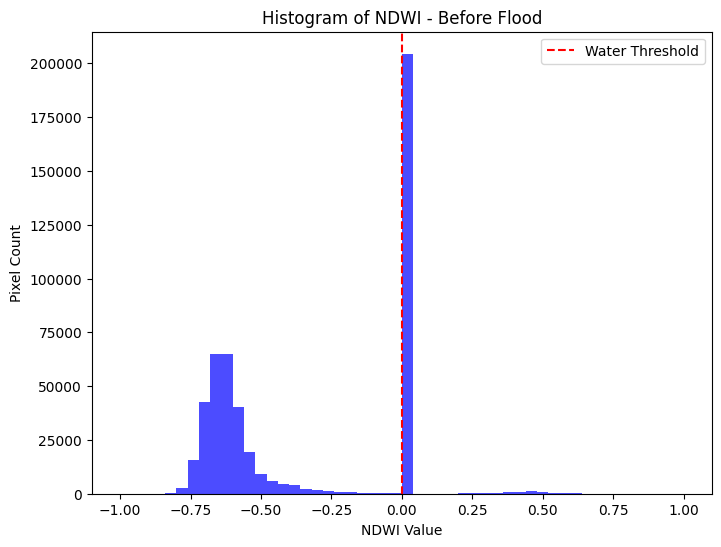

Water area in Before Flood: 1.35%


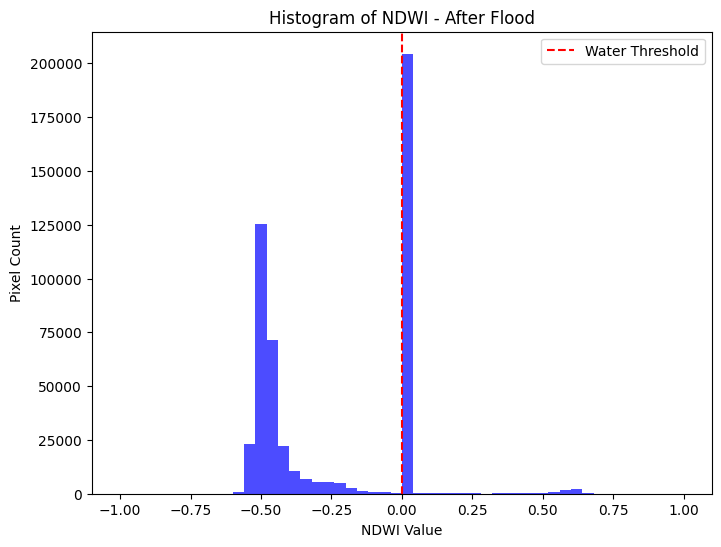

Water area in After Flood: 1.50%


In [18]:
# Function to calculate water pixels and plot histograms
def analyze_water(ndwi_array, title, threshold=0):
    # Classify water pixels based on NDWI threshold
    water_pixels = ndwi_array > threshold
    water_percentage = np.sum(water_pixels) / water_pixels.size * 100  # Calculate percentage

    # Plot histogram of NDWI values
    plt.figure(figsize=(8, 6))
    plt.hist(ndwi_array.flatten(), bins=50, range=(-1, 1), color='blue', alpha=0.7)
    plt.axvline(x=threshold, color='red', linestyle='--', label='Water Threshold')
    plt.xlabel("NDWI Value")
    plt.ylabel("Pixel Count")
    plt.title(f"Histogram of NDWI - {title}")
    plt.legend()
    plt.show()

    print(f"Water area in {title}: {water_percentage:.2f}%")

# Analyze water for both images
analyze_water(ndwi_pre, "Before Flood", threshold=0)
analyze_water(ndwi_post, "After Flood", threshold=0)

## Save as shapefile and raster

In [ ]:

# Function to save both shapefile and raster of water areas
def save_water_layer(ndwi_array, transform, output_shapefile, output_raster, raster_crs, threshold=0):
    # Create binary mask of water areas
    water_mask = (ndwi_array > threshold).astype(np.uint8)

    # --- Save as TIFF ---
    height, width = water_mask.shape
    with rasterio.open(
        output_raster,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=water_mask.dtype,
        crs=raster_crs,
        transform=transform
    ) as dst:
        dst.write(water_mask, 1)
    print(f" Raster TIFF saved to {output_raster}")

    # --- Convert mask to polygons and save as shapefile ---
    results = shapes(water_mask, mask=water_mask, transform=transform)
    geometries = [shape(geom) for geom, _ in results]
    gdf = gpd.GeoDataFrame({'geometry': geometries}, crs=raster_crs)
    gdf.to_file(output_shapefile)
    print(f" Shapefile saved to {output_shapefile} with CRS: {raster_crs}")

#CRS
with rasterio.open(post_flood_files[0]) as src:
    transform = src.transform
    raster_crs = src.crs

# Define output paths
output_shapefile = os.path.join(output_folder, f"{aoi_name}_flood_layer.shp")
output_raster = os.path.join(output_folder, f"{aoi_name}_flood_layer.tif")

# Run function
save_water_layer(ndwi_post, transform, output_shapefile, output_raster, raster_crs, threshold=0)

## Save metadata

In [ ]:
import json
from datetime import datetime
import geopandas as gpd
import glob
import os

# === Build flood period ===
flood_period = {
    "before": f"{BEFORE_EVENT_START} to {BEFORE_EVENT_END}",
    "after": f"{AFTER_EVENT_START} to {AFTER_EVENT_END}"
}

# === Count NDWI images ===
pre_images = glob.glob(os.path.join(pre_flood_folder, "*.tif"))
post_images = glob.glob(os.path.join(post_flood_folder, "*.tif"))

# === Attempt to load flood shapefile and compute flooded area ===
if os.path.exists(flood_shapefile):
    flood_gdf = gpd.read_file(flood_shapefile)
    if flood_gdf.crs and flood_gdf.crs.is_geographic:
        flood_gdf = flood_gdf.to_crs(epsg=3857)
    total_flooded_area_sqkm = round(flood_gdf.geometry.area.sum() / 1e6, 2)
else:
    print(f" Flood shapefile not found: {flood_shapefile}")
    total_flooded_area_sqkm = None

# === Compile metadata dictionary ===
metadata = {
    "flood_layer_calculated": "Sentinel-2",
    "pre_images_count": len(pre_images),
    "post_images_count": len(post_images),
    "aoi_name": aoi_name,
    "flood_period": flood_period,
    "image_date_range": [BEFORE_EVENT_START, AFTER_EVENT_END],
    "processed_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "outputpath_shapefile_name": flood_shapefile,
    "notes": "Auto-generated metadata during flood layer processing",
    "total_flooded_area_sqkm": total_flooded_area_sqkm
}

# === Save metadata to JSON in correct location ===
with open(metadata_output_path, "w") as f:
    json.dump(metadata, f, indent=4)

# Done
print(f" Metadata saved at: {metadata_output_path}")
print(json.dumps(metadata, indent=4))
